## Exercise 1: Chi-Squared and Some Basics

In [42]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
path = '/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exercises/Exercise 1/FranksNumbers.txt'

## Part 1

In [21]:
# Initialize an empty dictionary to store datasets
datasets = {}

# Open the file and read line by line
with open(path, 'r') as file:
    lines = file.readlines()  # Read all lines first
    
# Remove the first line (which is just a description in this case)
lines = lines[1:]

current_dataset = None
data = []

for line in lines:
    line = line.strip()                                                         # Remove leading/trailing whitespaces                        
    
    # Check if the line starts with "Data set" (i.e., a new dataset begins)
    if line.startswith("Data set"):
        if current_dataset is not None and data:
            # Convert accumulated data to a NumPy array and store it
            datasets[current_dataset] = np.array(data, dtype = float)
            data = []                                                           # Reset for the next dataset
        
        current_dataset = line                                                  # Store the dataset name
    elif line:                                                                  # If it's not empty, assume it's a data row
        values = line.split()
        if len(values) == 2:                                                    # Ensure there are exactly two columns
            data.append(list(map(float, values)))

# Store the last dataset
if current_dataset is not None and data:
    datasets[current_dataset] = np.array(data, dtype = float)

# Display dataset keys
print("Datasets loaded:", datasets.keys())

Datasets loaded: dict_keys(['Data set 1', 'Data set 2', 'Data set 3', 'Data set 4', 'Data set 5'])


In [29]:
# Display the datasets
for name, data in datasets.items():
    print(f"Dataset: {name}")
    print(data)
    print() 

Dataset: Data set 1
[[10.    8.04]
 [ 8.    6.95]
 [13.    7.58]
 [ 9.    8.81]
 [11.    8.33]
 [14.    9.96]
 [ 6.    7.24]
 [ 4.    4.26]
 [12.   10.84]
 [ 7.    4.82]
 [ 5.    5.68]]

Dataset: Data set 2
[[10.    9.14]
 [ 8.    8.14]
 [13.    8.74]
 [ 9.    8.77]
 [11.    9.26]
 [14.    8.1 ]
 [ 6.    6.13]
 [ 4.    3.1 ]
 [12.    9.13]
 [ 7.    7.26]
 [ 5.    4.74]]

Dataset: Data set 3
[[10.    7.46]
 [ 8.    6.77]
 [13.   12.74]
 [ 9.    7.11]
 [11.    7.81]
 [14.    8.84]
 [ 6.    6.08]
 [ 4.    5.39]
 [12.    8.15]
 [ 7.    6.42]
 [ 5.    5.73]]

Dataset: Data set 4
[[ 8.    6.58]
 [ 8.    5.76]
 [ 8.    7.71]
 [ 8.    8.84]
 [ 8.    8.47]
 [ 8.    7.04]
 [ 8.    5.25]
 [19.   12.5 ]
 [ 8.    5.56]
 [ 8.    7.91]
 [ 8.    6.89]]

Dataset: Data set 5
[[ 8.    6.58]
 [ 8.    5.76]
 [ 8.    7.71]
 [ 8.    8.84]
 [ 8.    8.47]
 [ 8.    7.04]
 [ 8.    5.25]
 [19.   12.5 ]
 [ 8.    5.56]
 [ 8.    7.91]
 [ 8.    6.89]
 [10.    7.46]
 [ 8.    6.77]
 [13.   12.74]
 [ 9.    7.11]
 [11.  

In [47]:
# Calculating the mean and variance for each data set
# The datasets contains X and Y values, so we need to calculate the mean and variance for each column
for key, value in datasets.items():
    mean = np.mean(value, axis = 0)
    variance = np.var(value, axis = 0)
    print(f"{key}, Mean: {mean}, Variance: {variance}")

Data set 1, Mean: [9.         7.50090909], Variance: [10.          3.75206281]
Data set 2, Mean: [9.         7.50090909], Variance: [10.          3.75239008]
Data set 3, Mean: [9.  7.5], Variance: [10.          3.74783636]
Data set 4, Mean: [9.         7.50090909], Variance: [10.          3.74840826]
Data set 5, Mean: [9.         7.50068182], Variance: [10.          3.75017454]


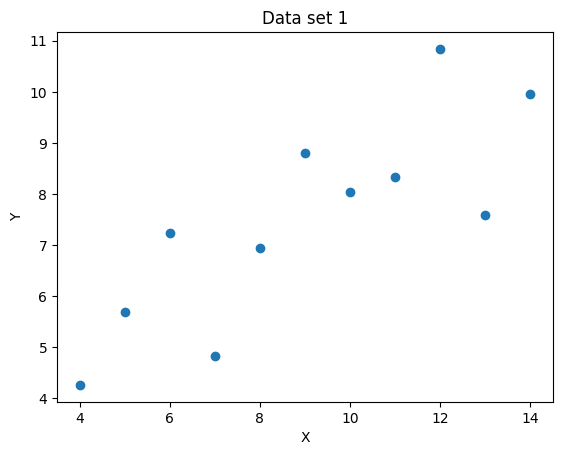

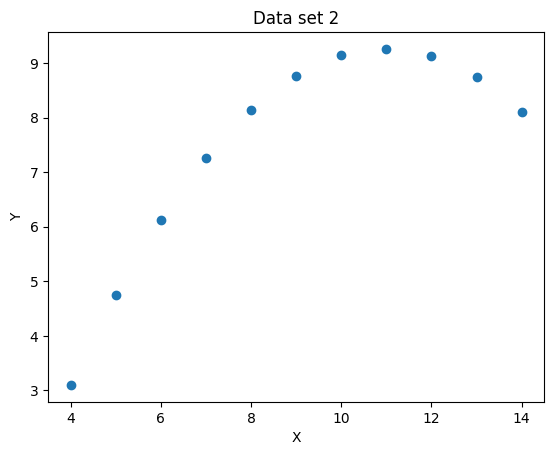

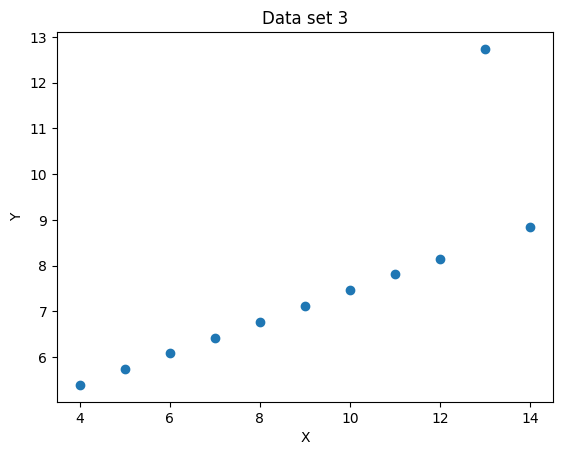

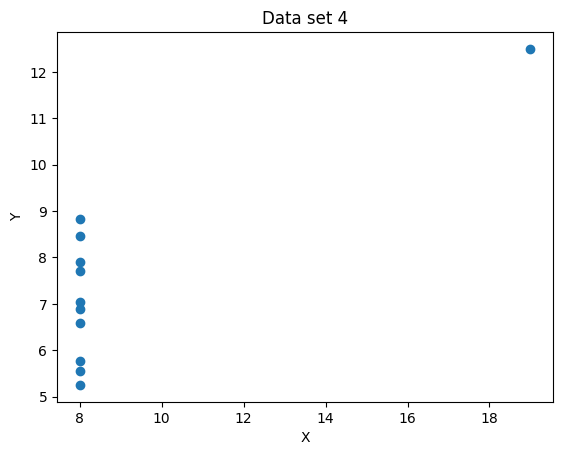

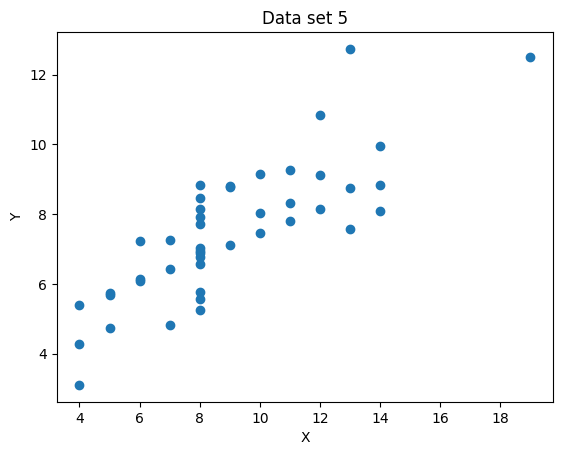

In [45]:
# Plotting the data sets in individual plots
for key, value in datasets.items():
    plt.scatter(value[:, 0], value[:, 1])
    plt.title(key)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()

## Part 2
Calculating the Pearson's $\chi^{2}$ for each of the 5 datasets using the following function: $Y = 0.48X + 3.02$.

In [32]:
# Assuming that the uncertainty on the Y-value is sqrt(Y-value)

# Calculating the uncertainty on the Y-value
for key, value in datasets.items():
    uncertainty = np.sqrt(value[:,1])
    print(f"{key}")
    print(f"Uncertainty on Y-value: {uncertainty}")
    print()

Data set 1
Uncertainty on Y-value: [2.83548938 2.63628527 2.75317998 2.96816442 2.88617394 3.15594677
 2.69072481 2.06397674 3.29241553 2.19544984 2.38327506]

Data set 2
Uncertainty on Y-value: [3.02324329 2.85306852 2.9563491  2.96141858 3.04302481 2.84604989
 2.47588368 1.76068169 3.02158899 2.69443872 2.17715411]

Data set 3
Uncertainty on Y-value: [2.73130006 2.60192237 3.56931366 2.66645833 2.79463772 2.97321375
 2.4657656  2.32163735 2.85482048 2.53377189 2.39374184]

Data set 4
Uncertainty on Y-value: [2.56515107 2.4        2.77668868 2.97321375 2.91032644 2.65329983
 2.29128785 3.53553391 2.35796522 2.81247222 2.62488095]

Data set 5
Uncertainty on Y-value: [2.56515107 2.4        2.77668868 2.97321375 2.91032644 2.65329983
 2.29128785 3.53553391 2.35796522 2.81247222 2.62488095 2.73130006
 2.60192237 3.56931366 2.66645833 2.79463772 2.97321375 2.4657656
 2.32163735 2.85482048 2.53377189 2.39374184 3.02324329 2.85306852
 2.9563491  2.96141858 3.04302481 2.84604989 2.47588368 1.

In [33]:
# Defining the chi-squared function 
def chi_squared(observed, expected, expected_uncertainty):
    return np.sum(((observed - expected) / expected_uncertainty) ** 2)

In [37]:
# Calculating the chi-squared value for each dataset using the function Y = 0.48X + 3.02
for key, value in datasets.items():
    X = value[:,0]
    Y = value[:,1]
    expected = 0.48 * X + 3.02
    expected_uncertainty = np.sqrt(Y)
    chi_squared_value = chi_squared(Y, expected, expected_uncertainty)
    print(f"{key}, Chi-squared value: {chi_squared_value}")

Data set 1, Chi-squared value: 1.8946085665619163
Data set 2, Chi-squared value: 2.4059899849668898
Data set 3, Chi-squared value: 1.2075802858304279
Data set 4, Chi-squared value: 2.01738262269104
Data set 5, Chi-squared value: 7.525561460050273


In [39]:
# Using the same function, but now with an uncertainty of +/- 1.22 on the Y-value
for key, value in datasets.items():
    X = value[:,0]
    Y = value[:,1]
    expected = 0.48 * X + 3.02
    expected_uncertainty = 1.22
    chi_squared_value = chi_squared(Y, expected, expected_uncertainty)
    print(f"{key}, Chi-squared value with uncertainty of +/- 1.22: {chi_squared_value}")

Data set 1, Chi-squared value with uncertainty of +/- 1.22: 9.46781779091642
Data set 2, Chi-squared value with uncertainty of +/- 1.22: 9.476686374630479
Data set 3, Chi-squared value with uncertainty of +/- 1.22: 9.460225745767271
Data set 4, Chi-squared value with uncertainty of +/- 1.22: 9.453708680462244
Data set 5, Chi-squared value with uncertainty of +/- 1.22: 37.85843859177643


Based on the $\chi^{2}$ values calculated with the error as $\sqrt{Y-value}$ and $\pm 1.22$, XX shows better agreement with the data. 